# Market Benchmarking Analysis

## Purpose
Compare internal compensation to external market data to ensure competitive positioning and identify retention risks.

## Key Metrics
- **Market Percentile**: Where employees fall in external market distribution
- **Competitive Ratio**: Company pay / Market 50th percentile
- **At-Risk Count**: Employees paid below 40th percentile (high flight risk)
- **Compression Ratio**: Manager pay / IC pay (should be ≥1.15)

## Research Foundation
- WorldatWork Total Rewards Survey methodology
- Radford Global Technology Survey
- Pay compression effects on retention (Trevor et al., 2012)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load datasets
if not os.path.exists('../data/employees_compensation.csv'):
    print("Generating sample data...")
    exec(open('../data/generate_sample_data.py').read())
else:
    print("Loading existing data...")

employees = pd.read_csv('../data/employees_compensation.csv')
market_data = pd.read_csv('../data/market_benchmark.csv')

print(f"\nLoaded {len(employees)} employee records")
print(f"Loaded {len(market_data)} market benchmark data points")

Loading existing data...

Loaded 500 employee records
Loaded 360 market benchmark data points


## 1. Overall Market Positioning

Assess where the company's pay falls relative to market.

OVERALL MARKET POSITIONING

Company Market Position:
  Average market percentile: 57.7
  Median market percentile:  55.6

Assessment: COMPETITIVE - Paying at market median

Market Percentile Distribution:
  Below 25th percentile:  46 (  9.2%) ⚠ HIGH FLIGHT RISK
  25th-50th percentile:  162 ( 32.4%)
  50th-75th percentile:  158 ( 31.6%)
  Above 75th percentile: 134 ( 26.8%)

⚠ AT-RISK EMPLOYEES (Below 40th Percentile):
  Count: 138 (27.6%)
  These employees are vulnerable to competitive offers



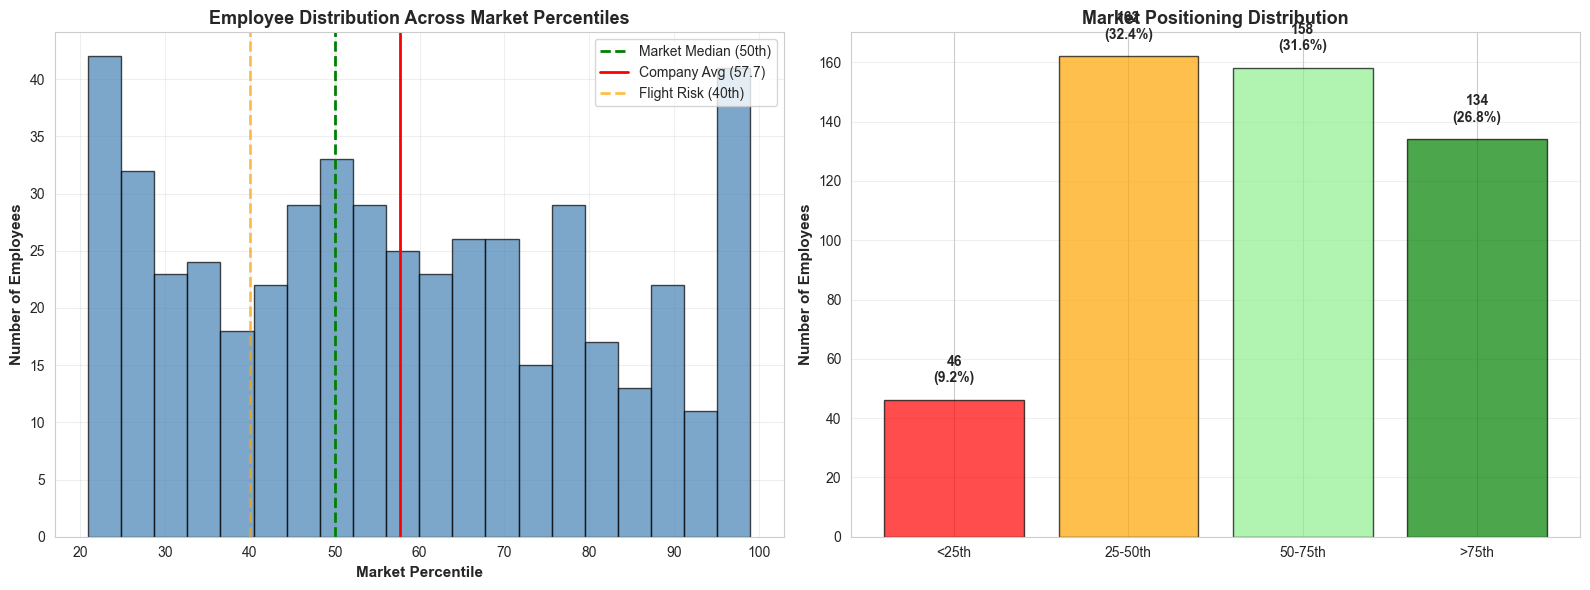

In [2]:
print(f"{'='*80}")
print(f"OVERALL MARKET POSITIONING")
print(f"{'='*80}")

# Overall statistics
avg_percentile = employees['market_percentile'].mean()
median_percentile = employees['market_percentile'].median()

print(f"\nCompany Market Position:")
print(f"  Average market percentile: {avg_percentile:.1f}")
print(f"  Median market percentile:  {median_percentile:.1f}")

if avg_percentile >= 75:
    assessment = "LEADING - Paying above 75th percentile"
elif avg_percentile >= 50:
    assessment = "COMPETITIVE - Paying at market median"
elif avg_percentile >= 40:
    assessment = "LAGGING - Below median, risk of losing talent"
else:
    assessment = "⚠ AT RISK - Significantly below market"

print(f"\nAssessment: {assessment}")

# Distribution by percentile range
print(f"\nMarket Percentile Distribution:")
below_25 = (employees['market_percentile'] < 25).sum()
p25_to_50 = ((employees['market_percentile'] >= 25) & (employees['market_percentile'] < 50)).sum()
p50_to_75 = ((employees['market_percentile'] >= 50) & (employees['market_percentile'] < 75)).sum()
above_75 = (employees['market_percentile'] >= 75).sum()

print(f"  Below 25th percentile: {below_25:3d} ({below_25/len(employees)*100:5.1f}%) ⚠ HIGH FLIGHT RISK")
print(f"  25th-50th percentile:  {p25_to_50:3d} ({p25_to_50/len(employees)*100:5.1f}%)")
print(f"  50th-75th percentile:  {p50_to_75:3d} ({p50_to_75/len(employees)*100:5.1f}%)")
print(f"  Above 75th percentile: {above_75:3d} ({above_75/len(employees)*100:5.1f}%)")

# At-risk employees (below 40th percentile)
at_risk = employees[employees['market_percentile'] < 40]
print(f"\n⚠ AT-RISK EMPLOYEES (Below 40th Percentile):")
print(f"  Count: {len(at_risk)} ({len(at_risk)/len(employees)*100:.1f}%)")
print(f"  These employees are vulnerable to competitive offers")

print(f"\n{'='*80}")

# Visualize market positioning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of percentiles
ax1.hist(employees['market_percentile'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(x=50, color='green', linestyle='--', linewidth=2, label='Market Median (50th)')
ax1.axvline(x=avg_percentile, color='red', linestyle='-', linewidth=2, label=f'Company Avg ({avg_percentile:.1f})')
ax1.axvline(x=40, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Flight Risk (40th)')
ax1.set_xlabel('Market Percentile', fontsize=11, fontweight='bold')
ax1.set_ylabel('Number of Employees', fontsize=11, fontweight='bold')
ax1.set_title('Employee Distribution Across Market Percentiles', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Percentile range breakdown
ranges = ['<25th', '25-50th', '50-75th', '>75th']
counts = [below_25, p25_to_50, p50_to_75, above_75]
colors_range = ['red', 'orange', 'lightgreen', 'green']

bars = ax2.bar(ranges, counts, color=colors_range, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Number of Employees', fontsize=11, fontweight='bold')
ax2.set_title('Market Positioning Distribution', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count in zip(bars, counts):
    pct = count / len(employees) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., count + 5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Market Positioning by Department and Level

Identify which roles are most/least competitive.

MARKET POSITIONING BY DEPARTMENT
                  Avg Percentile  Median Percentile  Count  Avg Salary  \
department                                                               
Sales                       54.6               50.1     58    287632.7   
Customer Success            55.8               55.6     70    230036.0   
Marketing                   56.1               55.2     59    227427.4   
Product                     57.5               55.8     60    261548.7   
Finance                     58.1               53.6     70    245271.7   
Operations                  58.1               56.4     71    224968.9   
Engineering                 59.6               60.2     47    257488.0   
HR                          61.5               61.0     65    241104.1   

                  Market 50th  Gap to Market  
department                                    
Sales                281854.1            2.1  
Customer Success     226059.3            1.8  
Marketing            221686.4         

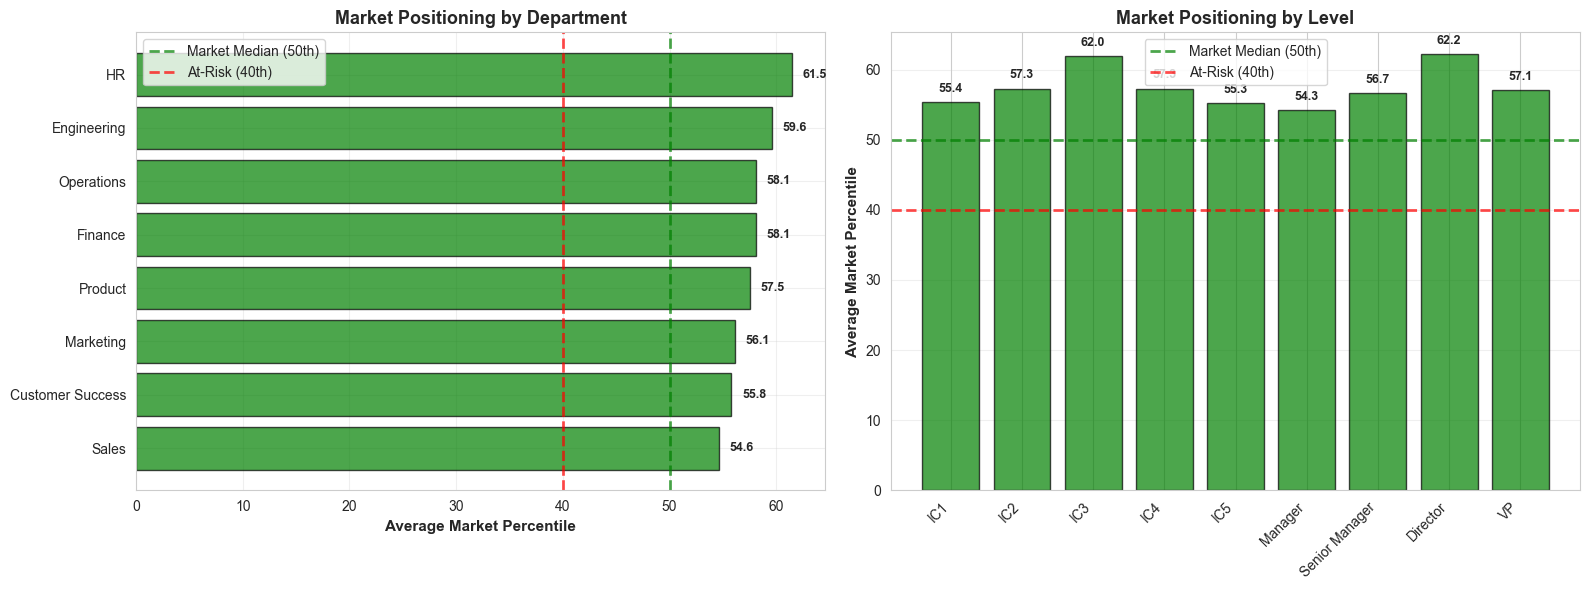

In [3]:
# Department-level analysis
print(f"{'='*80}")
print(f"MARKET POSITIONING BY DEPARTMENT")
print(f"{'='*80}")

dept_market = employees.groupby('department').agg({
    'market_percentile': ['mean', 'median'],
    'employee_id': 'count',
    'base_salary': 'mean',
    'market_50th': 'mean'
}).round(1)

dept_market.columns = ['Avg Percentile', 'Median Percentile', 'Count', 'Avg Salary', 'Market 50th']
dept_market['Gap to Market'] = ((dept_market['Avg Salary'] - dept_market['Market 50th']) / 
                                 dept_market['Market 50th'] * 100).round(1)
dept_market = dept_market.sort_values('Avg Percentile')

print(dept_market)

# Identify departments needing attention
low_paying_depts = dept_market[dept_market['Avg Percentile'] < 45]
if len(low_paying_depts) > 0:
    print(f"\n⚠ DEPARTMENTS BELOW COMPETITIVE LEVELS (< 45th percentile):")
    for dept in low_paying_depts.index:
        pct = low_paying_depts.loc[dept, 'Avg Percentile']
        gap = low_paying_depts.loc[dept, 'Gap to Market']
        count = int(low_paying_depts.loc[dept, 'Count'])
        print(f"  • {dept:20s}: {pct:.1f}th percentile ({gap:+.1f}% vs market) - {count} employees")

print(f"\n{'='*80}")

# Level-based analysis
print(f"\nMARKET POSITIONING BY LEVEL")
print(f"{'='*80}")

level_market = employees.groupby('level').agg({
    'market_percentile': ['mean', 'median'],
    'employee_id': 'count'
}).round(1)

level_market.columns = ['Avg Percentile', 'Median Percentile', 'Count']

# Sort by career progression
level_order = ['IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'Manager', 'Senior Manager', 'Director', 'VP']
level_market = level_market.reindex([l for l in level_order if l in level_market.index])

print(level_market)

# Identify levels needing attention
low_paying_levels = level_market[level_market['Avg Percentile'] < 45]
if len(low_paying_levels) > 0:
    print(f"\n⚠ LEVELS BELOW COMPETITIVE THRESHOLDS:")
    for level in low_paying_levels.index:
        pct = low_paying_levels.loc[level, 'Avg Percentile']
        count = int(low_paying_levels.loc[level, 'Count'])
        print(f"  • {level:15s}: {pct:.1f}th percentile - {count} employees at risk")

print(f"\n{'='*80}")

# Visualize by department and level
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Department positioning
colors_dept = ['red' if x < 45 else 'orange' if x < 50 else 'green' 
               for x in dept_market['Avg Percentile']]

bars1 = ax1.barh(dept_market.index, dept_market['Avg Percentile'], 
                 color=colors_dept, alpha=0.7, edgecolor='black')
ax1.axvline(x=50, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Market Median (50th)')
ax1.axvline(x=40, color='red', linestyle='--', linewidth=2, alpha=0.7, label='At-Risk (40th)')
ax1.set_xlabel('Average Market Percentile', fontsize=11, fontweight='bold')
ax1.set_title('Market Positioning by Department', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(dept_market.iterrows()):
    ax1.text(row['Avg Percentile'] + 1, i, f"{row['Avg Percentile']:.1f}", 
            va='center', fontsize=9, fontweight='bold')

# Level positioning
colors_level = ['red' if x < 45 else 'orange' if x < 50 else 'green' 
                for x in level_market['Avg Percentile']]

bars2 = ax2.bar(range(len(level_market)), level_market['Avg Percentile'], 
                color=colors_level, alpha=0.7, edgecolor='black')
ax2.axhline(y=50, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Market Median (50th)')
ax2.axhline(y=40, color='red', linestyle='--', linewidth=2, alpha=0.7, label='At-Risk (40th)')
ax2.set_xticks(range(len(level_market)))
ax2.set_xticklabels(level_market.index, rotation=45, ha='right')
ax2.set_ylabel('Average Market Percentile', fontsize=11, fontweight='bold')
ax2.set_title('Market Positioning by Level', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars2, level_market['Avg Percentile']):
    ax2.text(bar.get_x() + bar.get_width()/2., val + 1,
            f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Geographic Pay Differentials

Analyze cost-of-living adjustments and remote work pay policies.

GEOGRAPHIC PAY ANALYSIS
               Mean Salary  Median Salary  Count  Avg Percentile
location                                                        
San Francisco     278905.0       244029.0    110            53.0
New York          250897.0       220877.0     94            62.0
Austin            240735.0       226891.0    101            57.0
Seattle           237227.0       222109.0    101            56.0
Remote            215679.0       201584.0     94            62.0

💵 Cost-of-Living Adjusted Comparison:

Relative to San Francisco (highest COL):
  San Francisco       : $278,905 (+0.0% vs SF) - 110 employees
  New York            : $250,897 (-10.0% vs SF) - 94 employees
  Austin              : $240,735 (-13.7% vs SF) - 101 employees
  Seattle             : $237,227 (-14.9% vs SF) - 101 employees
  Remote              : $215,679 (-22.7% vs SF) - 94 employees

🏠 REMOTE WORKER PAY:
  Average: $215,679
  Count: 94 employees
  Policy: 77.3% of SF pay
  Assessment: ⚠ May struggle to a

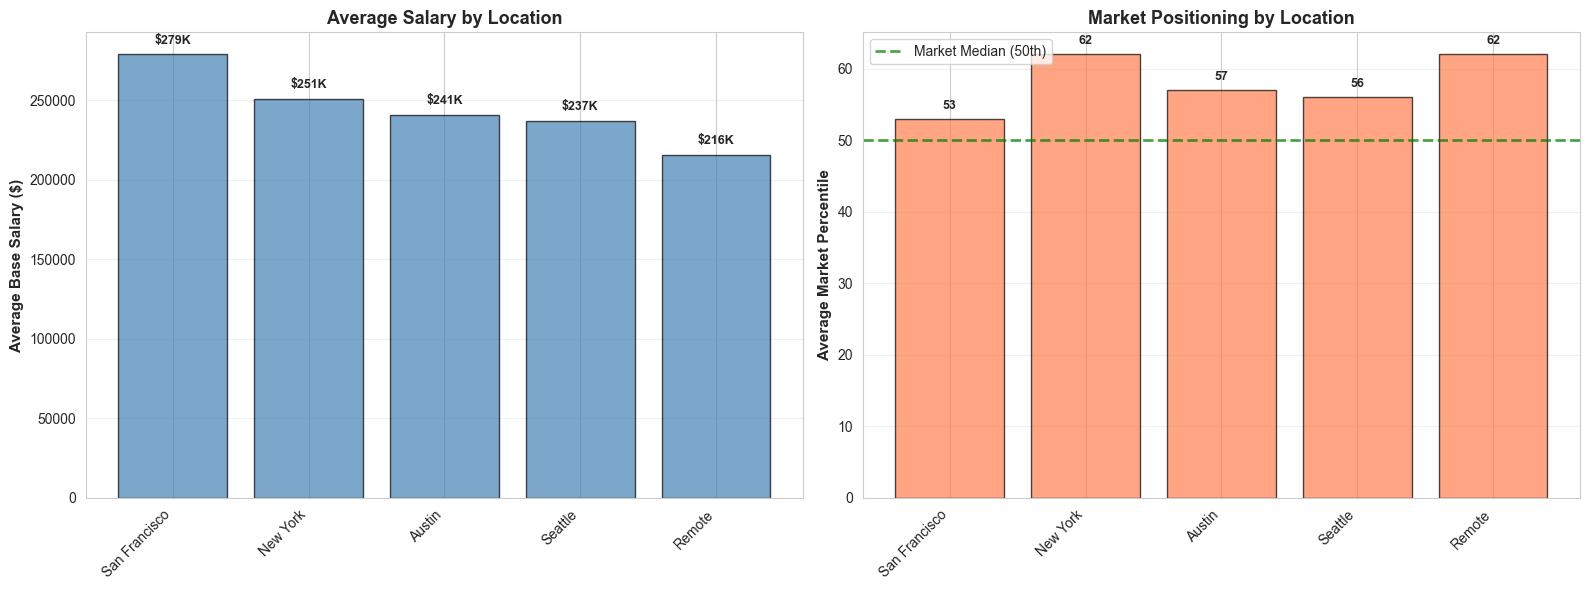

In [4]:
print(f"{'='*80}")
print(f"GEOGRAPHIC PAY ANALYSIS")
print(f"{'='*80}")

location_pay = employees.groupby('location').agg({
    'base_salary': ['mean', 'median', 'count'],
    'market_percentile': 'mean'
}).round(0)

location_pay.columns = ['Mean Salary', 'Median Salary', 'Count', 'Avg Percentile']
location_pay = location_pay.sort_values('Mean Salary', ascending=False)

print(location_pay)

# Calculate COL-adjusted comparison
sf_avg = location_pay.loc['San Francisco', 'Mean Salary'] if 'San Francisco' in location_pay.index else location_pay.iloc[0]['Mean Salary']

print(f"\n💵 Cost-of-Living Adjusted Comparison:")
print(f"{'='*80}")
print(f"\nRelative to San Francisco (highest COL):")
for loc in location_pay.index:
    avg = location_pay.loc[loc, 'Mean Salary']
    diff = ((avg - sf_avg) / sf_avg * 100)
    count = int(location_pay.loc[loc, 'Count'])
    print(f"  {loc:20s}: ${avg:,.0f} ({diff:+.1f}% vs SF) - {count} employees")

# Remote worker analysis
if 'Remote' in location_pay.index:
    remote_avg = location_pay.loc['Remote', 'Mean Salary']
    remote_count = int(location_pay.loc['Remote', 'Count'])
    print(f"\n🏠 REMOTE WORKER PAY:")
    print(f"  Average: ${remote_avg:,.0f}")
    print(f"  Count: {remote_count} employees")
    print(f"  Policy: {(remote_avg/sf_avg*100):.1f}% of SF pay")
    if remote_avg / sf_avg > 0.85:
        print(f"  Assessment: ✓ Competitive remote pay")
    else:
        print(f"  Assessment: ⚠ May struggle to attract remote talent")

print(f"\n{'='*80}")

# Visualize geographic pay
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Average salary by location
bars1 = ax1.bar(range(len(location_pay)), location_pay['Mean Salary'], 
                alpha=0.7, edgecolor='black', color='steelblue')
ax1.set_xticks(range(len(location_pay)))
ax1.set_xticklabels(location_pay.index, rotation=45, ha='right')
ax1.set_ylabel('Average Base Salary ($)', fontsize=11, fontweight='bold')
ax1.set_title('Average Salary by Location', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars1, location_pay['Mean Salary']):
    ax1.text(bar.get_x() + bar.get_width()/2., val + 5000,
            f'${val/1000:.0f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Market positioning by location
bars2 = ax2.bar(range(len(location_pay)), location_pay['Avg Percentile'], 
                alpha=0.7, edgecolor='black', color='coral')
ax2.axhline(y=50, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Market Median (50th)')
ax2.set_xticks(range(len(location_pay)))
ax2.set_xticklabels(location_pay.index, rotation=45, ha='right')
ax2.set_ylabel('Average Market Percentile', fontsize=11, fontweight='bold')
ax2.set_title('Market Positioning by Location', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars2, location_pay['Avg Percentile']):
    ax2.text(bar.get_x() + bar.get_width()/2., val + 1,
            f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Pay Compression Analysis

Assess whether managers are paid appropriately relative to their direct reports.

PAY COMPRESSION ANALYSIS

Average Pay by Level:
  IC1            : $94,419
  IC2            : $129,474
  IC3            : $174,145
  IC4            : $224,651
  IC5            : $291,967
  Manager        : $191,455
  Senior Manager : $238,634
  Director       : $322,936
  VP             : $455,758

📊 COMPRESSION RATIOS (Manager / IC):

Manager vs IC3:
  Manager avg: $191,455
  IC3 avg:     $174,145
  Ratio:       1.10:1
  ⚠ COMPRESSED: Managers should earn ≥15% more than ICs

Manager vs IC4:
  Manager avg: $191,455
  IC4 avg:     $224,651
  Ratio:       0.85:1
  ⚠ SEVERE COMPRESSION: Managers earning less than senior ICs

Senior Manager vs Manager:
  Senior Manager avg: $238,634
  Manager avg:        $191,455
  Ratio:              1.25:1
  ✓ ADEQUATE: Clear differentiation

Director vs Senior Manager:
  Director avg:        $322,936
  Senior Manager avg:  $238,634
  Ratio:               1.35:1
  ✓ ADEQUATE: Clear differentiation



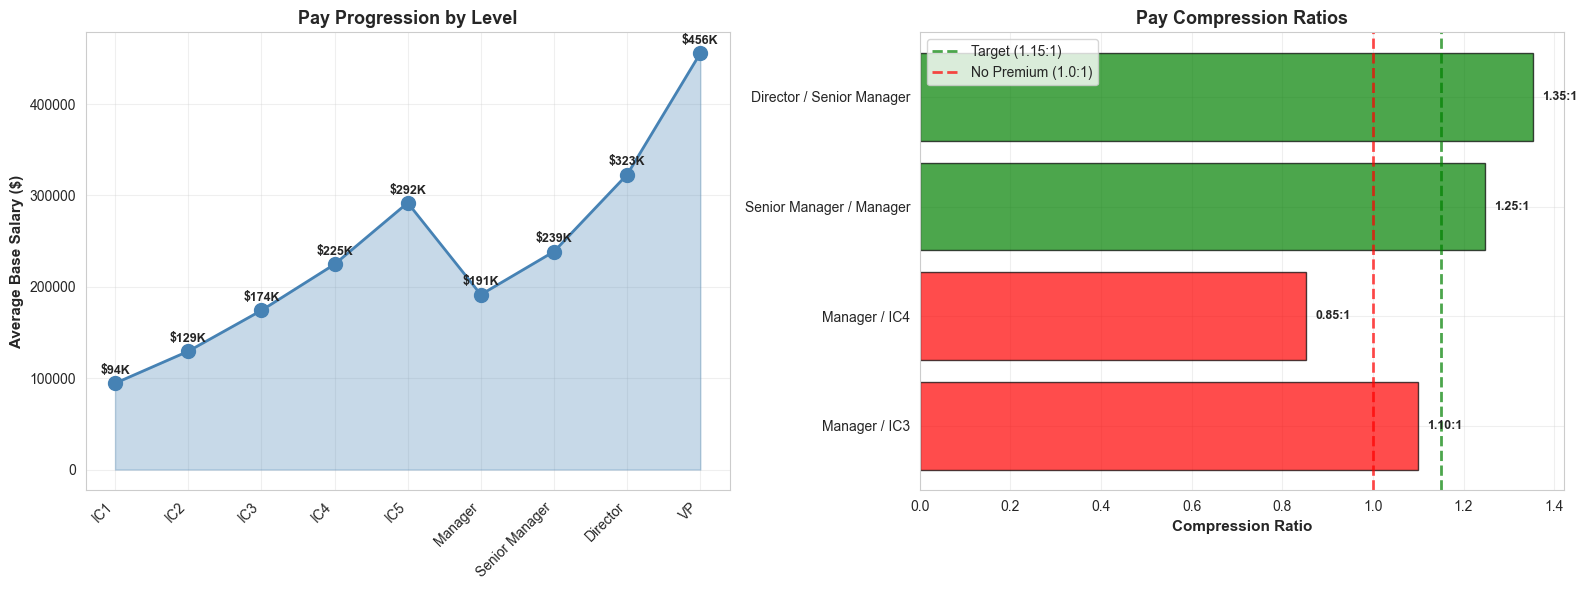

In [5]:
print(f"{'='*80}")
print(f"PAY COMPRESSION ANALYSIS")
print(f"{'='*80}")

# Calculate average pay by level
level_order = ['IC1', 'IC2', 'IC3', 'IC4', 'IC5', 'Manager', 'Senior Manager', 'Director', 'VP']
level_pay = employees.groupby('level')['base_salary'].mean()
level_pay = level_pay.reindex([l for l in level_order if l in level_pay.index])

print(f"\nAverage Pay by Level:")
for level in level_pay.index:
    print(f"  {level:15s}: ${level_pay[level]:,.0f}")

# Calculate compression ratios
print(f"\n📊 COMPRESSION RATIOS (Manager / IC):")
print(f"{'='*80}")

compression_ratios = {}

# Manager vs IC3/IC4
if 'Manager' in level_pay.index:
    manager_avg = level_pay['Manager']
    
    if 'IC3' in level_pay.index:
        ic3_avg = level_pay['IC3']
        ratio = manager_avg / ic3_avg
        compression_ratios['Manager / IC3'] = ratio
        print(f"\nManager vs IC3:")
        print(f"  Manager avg: ${manager_avg:,.0f}")
        print(f"  IC3 avg:     ${ic3_avg:,.0f}")
        print(f"  Ratio:       {ratio:.2f}:1")
        if ratio < 1.15:
            print(f"  ⚠ COMPRESSED: Managers should earn ≥15% more than ICs")
        else:
            print(f"  ✓ ADEQUATE: Appropriate manager premium")
    
    if 'IC4' in level_pay.index:
        ic4_avg = level_pay['IC4']
        ratio = manager_avg / ic4_avg
        compression_ratios['Manager / IC4'] = ratio
        print(f"\nManager vs IC4:")
        print(f"  Manager avg: ${manager_avg:,.0f}")
        print(f"  IC4 avg:     ${ic4_avg:,.0f}")
        print(f"  Ratio:       {ratio:.2f}:1")
        if ratio < 0.95:
            print(f"  ⚠ SEVERE COMPRESSION: Managers earning less than senior ICs")
        elif ratio < 1.10:
            print(f"  ⚠ COMPRESSED: Insufficient manager premium")
        else:
            print(f"  ✓ ADEQUATE: Appropriate differential")

# Senior Manager vs Manager
if 'Senior Manager' in level_pay.index and 'Manager' in level_pay.index:
    sm_avg = level_pay['Senior Manager']
    mgr_avg = level_pay['Manager']
    ratio = sm_avg / mgr_avg
    compression_ratios['Senior Manager / Manager'] = ratio
    print(f"\nSenior Manager vs Manager:")
    print(f"  Senior Manager avg: ${sm_avg:,.0f}")
    print(f"  Manager avg:        ${mgr_avg:,.0f}")
    print(f"  Ratio:              {ratio:.2f}:1")
    if ratio < 1.15:
        print(f"  ⚠ COMPRESSED: Insufficient premium for senior role")
    else:
        print(f"  ✓ ADEQUATE: Clear differentiation")

# Director vs Senior Manager
if 'Director' in level_pay.index and 'Senior Manager' in level_pay.index:
    dir_avg = level_pay['Director']
    sm_avg = level_pay['Senior Manager']
    ratio = dir_avg / sm_avg
    compression_ratios['Director / Senior Manager'] = ratio
    print(f"\nDirector vs Senior Manager:")
    print(f"  Director avg:        ${dir_avg:,.0f}")
    print(f"  Senior Manager avg:  ${sm_avg:,.0f}")
    print(f"  Ratio:               {ratio:.2f}:1")
    if ratio < 1.15:
        print(f"  ⚠ COMPRESSED: Insufficient premium for director role")
    else:
        print(f"  ✓ ADEQUATE: Clear differentiation")

print(f"\n{'='*80}")

# Visualize pay progression
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Career ladder pay progression
ax1.plot(range(len(level_pay)), level_pay.values, marker='o', linewidth=2, 
            markersize=10, color='steelblue')
ax1.fill_between(range(len(level_pay)), level_pay.values, alpha=0.3, color='steelblue')
ax1.set_xticks(range(len(level_pay)))
ax1.set_xticklabels(level_pay.index, rotation=45, ha='right')
ax1.set_ylabel('Average Base Salary ($)', fontsize=11, fontweight='bold')
ax1.set_title('Pay Progression by Level', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

# Add value labels
for i, val in enumerate(level_pay.values):
    ax1.text(i, val + 10000, f'${val/1000:.0f}K', ha='center', fontsize=9, fontweight='bold')

# Compression ratios
if len(compression_ratios) > 0:
    ratios_df = pd.DataFrame(list(compression_ratios.items()), columns=['Comparison', 'Ratio'])
    colors_comp = ['red' if x < 1.10 else 'orange' if x < 1.15 else 'green' 
                   for x in ratios_df['Ratio']]
    
    bars = ax2.barh(ratios_df['Comparison'], ratios_df['Ratio'], 
                    color=colors_comp, alpha=0.7, edgecolor='black')
    ax2.axvline(x=1.15, color='green', linestyle='--', linewidth=2, alpha=0.7, label='Target (1.15:1)')
    ax2.axvline(x=1.0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='No Premium (1.0:1)')
    ax2.set_xlabel('Compression Ratio', fontsize=11, fontweight='bold')
    ax2.set_title('Pay Compression Ratios', fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Add value labels
    for i, (idx, row) in enumerate(ratios_df.iterrows()):
        ax2.text(row['Ratio'] + 0.02, i, f"{row['Ratio']:.2f}:1", 
                va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Retention Risk Assessment

Identify employees most likely to leave due to uncompetitive pay.

In [6]:
# Identify high-risk employees
high_risk = employees[employees['market_percentile'] < 25].copy()
high_risk = high_risk.sort_values('market_percentile')

print(f"{'='*80}")
print(f"COMPETITIVE RETENTION RISK ASSESSMENT")
print(f"{'='*80}")

print(f"\n⚠ HIGH FLIGHT RISK: Employees below 25th percentile")
print(f"  Total count: {len(high_risk)} ({len(high_risk)/len(employees)*100:.1f}%)")
print(f"  These employees are highly vulnerable to competitive offers")

# Breakdown by level
print(f"\nBreakdown by Level:")
risk_by_level = high_risk['level'].value_counts()
for level, count in risk_by_level.items():
    total_at_level = len(employees[employees['level'] == level])
    pct = count / total_at_level * 100
    print(f"  {level:15s}: {count} at risk ({pct:.1f}% of {level}s)")

# Breakdown by department
print(f"\nBreakdown by Department:")
risk_by_dept = high_risk['department'].value_counts()
for dept, count in risk_by_dept.items():
    total_in_dept = len(employees[employees['department'] == dept])
    pct = count / total_in_dept * 100
    print(f"  {dept:20s}: {count} at risk ({pct:.1f}% of {dept})")

# Calculate cost to bring to market
print(f"\n💰 COST TO ADDRESS RETENTION RISK:")
print(f"{'='*80}")

# Bring all high-risk employees to 50th percentile
total_adjustment_needed = high_risk['adjustment_to_50th'].sum()
avg_adjustment_per_person = high_risk['adjustment_to_50th'].mean()
avg_adjustment_pct = (high_risk['adjustment_to_50th'] / high_risk['base_salary']).mean() * 100

print(f"\nScenario: Bring all high-risk employees to market median (50th percentile)")
print(f"  Total annual cost:  ${total_adjustment_needed:,.0f}")
print(f"  Average per person: ${avg_adjustment_per_person:,.0f} ({avg_adjustment_pct:.1f}% increase)")
print(f"  Affected employees: {len(high_risk)}")

# ROI calculation
avg_salary = employees['base_salary'].mean()
turnover_cost = avg_salary * 1.5  # 1.5x salary to replace
prevented_departures = len(high_risk) * 0.3  # Assume 30% would leave
savings = prevented_departures * turnover_cost
roi = savings / total_adjustment_needed if total_adjustment_needed > 0 else 0

print(f"\nROI Analysis:")
print(f"  Assumed retention improvement: 30% fewer departures")
print(f"  Departures prevented: {prevented_departures:.1f}")
print(f"  Cost per departure: ${turnover_cost:,.0f}")
print(f"  Total savings: ${savings:,.0f}")
print(f"  ROI: {roi:.1f}:1")

if roi > 2:
    print(f"  ✓ STRONG ROI: Adjustments pay for themselves through retention")
elif roi > 1:
    print(f"  → POSITIVE ROI: Investment justified")
else:
    print(f"  ⚠ MARGINAL ROI: Consider selective adjustments")

# Top 10 highest-risk individuals
print(f"\n{'='*80}")
print(f"TOP 10 HIGHEST RETENTION RISK (for immediate review)")
print(f"{'='*80}")

top_risk = high_risk.head(10)[[
    'employee_id', 'level', 'department', 'market_percentile', 
    'base_salary', 'market_50th', 'adjustment_to_50th'
]]

top_risk.columns = ['ID', 'Level', 'Department', 'Percentile', 
                    'Current Pay', 'Market 50th', 'Adjustment Needed']

print(top_risk.to_string(index=False))
print(f"\n{'='*80}")

COMPETITIVE RETENTION RISK ASSESSMENT

⚠ HIGH FLIGHT RISK: Employees below 25th percentile
  Total count: 46 (9.2%)
  These employees are highly vulnerable to competitive offers

Breakdown by Level:
  VP             : 14 at risk (19.7% of VPs)
  IC5            : 7 at risk (15.9% of IC5s)
  Director       : 6 at risk (9.2% of Directors)
  Manager        : 4 at risk (7.3% of Managers)
  Senior Manager : 4 at risk (6.9% of Senior Managers)
  IC2            : 4 at risk (7.1% of IC2s)
  IC4            : 3 at risk (6.0% of IC4s)
  IC1            : 2 at risk (4.2% of IC1s)
  IC3            : 2 at risk (3.8% of IC3s)

Breakdown by Department:
  Customer Success    : 9 at risk (12.9% of Customer Success)
  Marketing           : 7 at risk (11.9% of Marketing)
  Finance             : 6 at risk (8.6% of Finance)
  Sales               : 6 at risk (10.3% of Sales)
  Operations          : 5 at risk (7.0% of Operations)
  Product             : 5 at risk (8.3% of Product)
  HR                  : 4 at r

## Key Takeaways

1. **Market positioning determines competitiveness**: Employees below 40th percentile are at high flight risk
2. **Not all roles are equally competitive**: Identify specific departments and levels needing adjustment
3. **Pay compression demotivates promotions**: Managers should earn ≥15% more than direct reports
4. **Prevention is cheaper than replacement**: Proactive adjustments have strong ROI through retention

**Recommended Next Steps**:
- Immediately address employees below 25th percentile (highest flight risk)
- Develop multi-year plan to bring all roles to at least 40th percentile
- Fix pay compression issues to maintain promotion motivation
- Establish quarterly market benchmarking cadence to stay competitive